# Lab: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor


## 1. Data Setup and Exploration
*Estimated time: 30–40 min*

### Objective  
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the GIST Steel dataset. 
- Display basic info (shape, column names, missing values, and data types).  
- Identify the target variable (production) and key features (capacity, ...).

> *Markdown prompt:*  
Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?

---

In [3]:
# Set the file path
file_path = "Plant-level-data-Global-Iron-and-Steel-Tracker.xlsx"

# Load all necessary sheets
sheets = ["Plant data", "Plant capacities and status", "Plant production"]
dfs = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in sheets}

# Check that 'Plant ID' exists in each dataframe
for name, df in dfs.items():
    if 'Plant ID' not in df.columns:
        raise ValueError(f"'Plant ID' missing in sheet '{name}'")

# Function to select columns to merge
def select_merge_cols(base_df, new_df):
    cols = [col for col in new_df.columns if col not in base_df.columns or col == 'Plant ID']
    return new_df[cols]

# Merge the DataFrames with inner join to keep only the factories present in the 3 datasets
df_merged = dfs["Plant data"]
for sheet in sheets[1:]:
    df_merged = pd.merge(df_merged, 
                         select_merge_cols(df_merged, dfs[sheet]), 
                         on='Plant ID', 
                         how='inner')

In [4]:
# Display information about the merged dataset
print("=== Merged Dataset Information ===")
print(f"Total number of rows: {df_merged.shape[0]}")
print(f"Total number of columns: {df_merged.shape[1]}")
print(f"Number of unique Plant IDs: {df_merged['Plant ID'].nunique()}")
print(f"Number of duplicate Plant IDs: {df_merged.duplicated(subset='Plant ID').sum()}")

# Preview the dataset
print("\nPreview of the first rows:")
df_merged.head()

=== Merged Dataset Information ===
Total number of rows: 3243
Total number of columns: 61
Number of unique Plant IDs: 476
Number of duplicate Plant IDs: 2767

Preview of the first rows:


,Plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM ID,Owner PermID,SOE Status,...,Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa),Type of production,2019,2020,2021,2022,2023,2024
0,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,Crude steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
1,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,BOF steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
2,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,EAF steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
3,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,Iron production (ttpa),560,unknown,unknown,unknown,unknown,unknown
4,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,BF iron production (ttpa),560,unknown,unknown,unknown,unknown,unknown


For this analysis, we will focus exclusively on currently operational steel production facilities.

In [5]:
# Filter only operational plants
operating_plants = df_merged[df_merged['Status'].str.lower() == 'operating'].reset_index(drop=True)

# Dataset shape
num_rows, num_cols = operating_plants.shape
print(f"Operational plants dataset shape: {num_rows} rows x {num_cols} columns")

# Count unique Plant IDs
unique_plants = operating_plants['Plant ID'].nunique()
print(f"Number of unique operational plants: {unique_plants:,}")

Operational plants dataset shape: 1566 rows x 61 columns
Number of unique operational plants: 423


In [6]:
# Replace 'unknown' (case-insensitive) with NaN
operating_plants = operating_plants.replace(to_replace=r'(?i)^unknown$', value=np.nan, regex=True)
pd.set_option('future.no_silent_downcasting', True)

# Create summary table
summary_table = pd.DataFrame({
    "Column Name": operating_plants.columns,
    "Data Type": operating_plants.dtypes.values,
    "Missing Values": operating_plants.isnull().sum().values,
    "Missing (%)": (operating_plants.isnull().sum() / len(operating_plants) * 100).round(2).values
})

# Display the summary table
print("=== Operating Plants Dataset Summary (including 'unknown' as missing) ===")
display(summary_table)

=== Operating Plants Dataset Summary (including 'unknown' as missing) ===


C:\Users\kerri\AppData\Local\Temp\ipykernel_16260\632820204.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  operating_plants = operating_plants.replace(to_replace=r'(?i)^unknown$', value=np.nan, regex=True)


,Column Name,Data Type,Missing Values,Missing (%)
0,Plant ID,object,0,0.00
1,Plant name (English),object,0,0.00
2,Plant name (other language),object,628,40.10
3,Other plant names (English),object,463,29.57
4,Other plant names (other language),object,1089,69.54
...,...,...,...,...
56,2020,object,819,52.30
57,2021,object,881,56.26
58,2022,object,844,53.90
59,2023,object,843,53.83


Our preliminary analysis highlights several data quality issues that must be addressed before proceeding with the modeling process:

1. **High Proportion of Missing Values:**

    - Several columns exhibit substantial missingness, with some exceeding 70% null entries.
    - Such extensive gaps in the data may compromise the robustness and reliability of subsequent analyses.

2. **Inconsistent Data Types:**

    - All columns are currently stored as object (string) types.
    - This indicates potential inconsistencies in data representation that must be corrected to enable accurate computation and modeling.

3. **Necessary Data Cleaning Steps:**

    - Appropriate imputation or removal strategies will be applied to handle missing values.
    - Data type conversions will be performed to ensure numerical and categorical variables are properly formatted.
    - Validation checks will be implemented to verify data consistency and integrity.

Addressing these issues is essential to ensure the validity, reliability, and overall quality of our subsequent analysis.

For this predictive modeling task, our focus is on forecasting crude steel production across manufacturing facilities. The analysis will:

- Define crude steel output as the primary target variable.
- Emphasize production-related features and their principal determinants.
- Exclude variables unrelated to the production process to avoid noise and redundancy.
- Maintain a clear focus on factors that directly influence steel production.

This focused approach is designed to enhance both the accuracy and interpretability of our forecasting models, ensuring that the results remain directly relevant to operational and strategic decision-making.

In [7]:
# Filter for crude steel production plants
crude_steel_plants = operating_plants[
    operating_plants['Type of production'].str.lower() == 'crude steel production (ttpa)'
].reset_index(drop=True)

# Dataset shape
num_rows, num_cols = crude_steel_plants.shape
print(f"Crude steel production plants dataset shape: {num_rows} rows x {num_cols} columns")

# Count unique Plant IDs
unique_plants = crude_steel_plants['Plant ID'].nunique()
print(f"Number of unique crude steel production plants: {unique_plants:,}")

# Optional preview
print("\nPreview of crude steel production plants:")
crude_steel_plants.head()

Crude steel production plants dataset shape: 411 rows x 61 columns
Number of unique crude steel production plants: 411

Preview of crude steel production plants:


,Plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM ID,Owner PermID,SOE Status,...,Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa),Type of production,2019,2020,2021,2022,2023,2024
0,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5.000942e+09,Full,...,1500.0,NaN,NaN,Crude steel production (ttpa),NaN,NaN,NaN,NaN,NaN,NaN
1,P100000120441,Tosyali Algerie Oran steel plant,شركة توسيالي الجزائرية التركية للحديد والصلب,NaN,Tosyali Algérie,Tosyali Ironsteel Industry Algerie SpA,NaN,E100000131071,5.074197e+09,NaN,...,NaN,5000.0,NaN,Crude steel production (ttpa),NaN,NaN,NaN,NaN,NaN,NaN
2,P100000120006,ArcelorMittal Acindar Villa Constitución steel...,Planta siderúrgica Acindar,NaN,NaN,Acindar Industria Argentina de Aceros SA,NaN,E100001010109,4.295856e+09,NaN,...,NaN,600.0,NaN,Crude steel production (ttpa),1100,800,1252,1174,1100,NaN
3,P100000120009,Gerdau Sipar Pérez steel plant,Planta siderúrgica Gerdau Sipar Pérez,NaN,Gerdau Ludueña,Sipar Aceros SA,NaN,E100001010274,5.035931e+09,NaN,...,NaN,NaN,NaN,Crude steel production (ttpa),167,182,219,372,356,NaN
4,P100000120007,TenarisSiderca Campana steel plant,Planta siderúrgica TenarisSiderca,Tenaris Siderca Seamless Tubes Mill,"Dálmine Siderca (predecessor), Dálmine Safta (...",Siderca SAIC,NaN,E100000001765,4.295856e+09,NaN,...,NaN,960.0,NaN,Crude steel production (ttpa),878,694,873,922,910,NaN


We remove all columns that are either irrelevant to our prediction task, redundant, or contain excessive missing values. For instance, the ‘Start date’ and ‘Plant age’ columns convey the same information, making one of them unnecessary. Similarly, the 2024 column is excluded due to its 99% missing values. In addition, variables related to plant ownership or iron production are considered insufficiently relevant, as our objective is to predict crude steel production.

In [8]:
# Convert column names to strings
crude_steel_plants.columns = crude_steel_plants.columns.astype(str)

# List of columns to drop
cols_to_drop = [

    # Plant and owner info
    "Plant ID", "Plant name (English)", "Plant name (other language)", "Other plant names (English)", "Other plant names (other language)",
    "Owner", "Owner (other language)", "Owner GEM ID", "Owner PermID", "SOE Status",
    "Parent", "Parent GEM ID", "Parent PermID", "Status", "Type of production", "Main production equipment",

    # Location info
    "Country/Area", "Location address", "Municipality", "Other language location address", 
    "Coordinates", "Coordinate accuracy", "GEM wiki page", "Subnational unit (province/state)",

    # Dates
    "Announced date", "Construction date", "Pre-retirement announcement date", 
    "Idled date", "Retired date", "Start date",

    # Capacities and products
    "Ferronickel capacity (ttpa)", "Sinter plant capacity (ttpa)", "Coking plant capacity (ttpa)",
    "Pelletizing plant capacity (ttpa)", "Category steel product", "Steel products", "Steel sector end users",

    # Iron production
    "Nominal iron capacity (ttpa)", "Nominal BF capacity (ttpa)", "Nominal DRI capacity (ttpa)",
    "Other/unspecified iron capacity (ttpa)",

    # Steel production
    "2024",

    # Sources
    "Power source", "Iron ore source", "Met coal source"
]

# Determine which columns actually exist in the dataset
existing_cols_to_drop = [col for col in cols_to_drop if col in crude_steel_plants.columns]

# Drop the columns
crude_steel_plants = crude_steel_plants.drop(columns=existing_cols_to_drop)

# Print summary
print(f"Dropped columns: {len(existing_cols_to_drop)}")
print(f"Cleaned dataset: {crude_steel_plants.shape[1]} remaining columns, {crude_steel_plants.shape[0]} rows.\n")

# Preview the cleaned dataset
crude_steel_plants.head()

Dropped columns: 45
Cleaned dataset: 16 remaining columns, 411 rows.



,Region,Plant age (years),Workforce size,ISO 14001,ISO 50001,ResponsibleSteel Certification,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal OHF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),2019,2020,2021,2022,2023
0,Africa,56.00,5748.0,NaN,NaN,No,2150,350.0,1800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa,12.00,8000.0,Yes,NaN,No,6200,NaN,6200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Central & South America,79.00,1624.0,2020,NaN,No,2000,NaN,2000.0,NaN,NaN,1100,800,1252,1174,1100
3,Central & South America,8.00,787.0,2022,NaN,No,650,NaN,650.0,NaN,NaN,167,182,219,372,356
4,Central & South America,65.13,2993.0,2022-07-19 00:00:00,2017-07-22 00:00:00,No,1720,NaN,1720.0,NaN,NaN,878,694,873,922,910


For our prediction task, we retained variables related to the production capacities of crude steel plants, their historical production data from 2019 to 2023, the age of the facilities, their geographical location, the number of employees, and information regarding their environmental certifications.

More specifically, we selected crude steel production in 2023 (and potentially in subsequent years) as the target variable for our prediction. The variables expected to exert the greatest influence on crude steel output include historical production levels, plant capacity, and the number of employees. Nonetheless, additional factors such as environmental certifications may provide complementary insights, helping the model capture more complex and nuanced patterns within the data.

In [9]:
# Current year columns
year_cols = ["2019", "2020", "2021", "2022", "2023"]

# Generate new names
new_names = [f"production_{year}" for year in year_cols]
rename_dict = dict(zip(year_cols, new_names))

# Rename columns
crude_steel_plants = crude_steel_plants.rename(columns=rename_dict)
print(crude_steel_plants.columns)

Index(['Region', 'Plant age (years)', 'Workforce size', 'ISO 14001',
       'ISO 50001', 'ResponsibleSteel Certification',
       'Nominal crude steel capacity (ttpa)',
       'Nominal BOF steel capacity (ttpa)',
       'Nominal EAF steel capacity (ttpa)',
       'Nominal OHF steel capacity (ttpa)',
       'Other/unspecified steel capacity (ttpa)', 'production_2019',
       'production_2020', 'production_2021', 'production_2022',
       'production_2023'],
      dtype='object')


### **Task 1.2 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).  
- Check for outliers or incorrect entries in numerical columns.  
- Apply transformations if needed (e.g., log-transform for skewed distributions).

> *Markdown prompt:*  
Explain your cleaning choices. Why did you treat the missing or skewed data in that way?

---

In [10]:
# Compute missing and 'unknown' per column
missing_or_unknown = crude_steel_plants.isnull().sum()

# Print results by column
print("=== Missing or Unknown Values per Column ===")
for col, count in missing_or_unknown.items():
    print(f"{col}: {count}")

=== Missing or Unknown Values per Column ===
Region: 0
Plant age (years): 5
Workforce size: 22
ISO 14001: 62
ISO 50001: 227
ResponsibleSteel Certification: 0
Nominal crude steel capacity (ttpa): 12
Nominal BOF steel capacity (ttpa): 241
Nominal EAF steel capacity (ttpa): 170
Nominal OHF steel capacity (ttpa): 410
Other/unspecified steel capacity (ttpa): 386
production_2019: 205
production_2020: 173
production_2021: 181
production_2022: 167
production_2023: 158


First, we decided to remove factories with missing values in the Nominal crude steel capacity column because this variable is essential for our analysis. Without this information, it is impossible to accurately assess the production potential of the factory or to include it reliably in the predictive model. Imputing these values could introduce significant bias, as capacity is a fundamental determinant of production output. Therefore, dropping these rows ensures the integrity and reliability of our dataset.

In [11]:
# First, convert the column to numeric, coercing errors into NaN
crude_steel_plants['Nominal crude steel capacity (ttpa)'] = pd.to_numeric(
    crude_steel_plants['Nominal crude steel capacity (ttpa)'], errors='coerce'
)

# Now drop rows where it is NaN
crude_steel_plants = crude_steel_plants.dropna(subset=['Nominal crude steel capacity (ttpa)'])

print(f"Rows remaining: {crude_steel_plants.shape[0]}")

Rows remaining: 398


Since factories do not all produce the same type of crude steel, several nominal sub-capacity fields contain missing values. To clean the dataset, we imputed these missing values with zeros and verified that the sum of the nominal sub-capacities equals the total nominal capacity, thereby ensuring data consistency and integrity. If this condition holds, the imputations will not affect the validity of the model or introduce bias.

In [12]:
# List of capacity columns
capacity_cols = [
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal OHF steel capacity (ttpa)",
    "Other/unspecified steel capacity (ttpa)",
    "Nominal crude steel capacity (ttpa)"
]

# Convert all relevant columns to numeric (coerce errors -> NaN)
for col in capacity_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Replace NaN with zeros in the four component columns
component_cols = capacity_cols[:-1]  # all except total
crude_steel_plants[component_cols] = crude_steel_plants[component_cols].fillna(0)

# Calculate total from components
crude_steel_plants["Calculated total capacity"] = crude_steel_plants[component_cols].sum(axis=1)

# Compare calculated vs reported total
comparison = (
    crude_steel_plants["Calculated total capacity"].round(2)
    == crude_steel_plants["Nominal crude steel capacity (ttpa)"].round(2)
)

crude_steel_plants.drop(columns=["Calculated total capacity"], inplace=True)

# Summary stats
matches = comparison.sum()
total = len(comparison)
print(f"Matching rows: {matches:,} out of {total:,} ({matches/total*100:.2f}%)")

# Inspect mismatches if any
mismatched = crude_steel_plants[~comparison]
print(f"Mismatched rows: {len(mismatched):,}")

Matching rows: 398 out of 398 (100.00%)
Mismatched rows: 0


Having verified the integrity of the factories’ capacity data, we decided to simplify the prediction task and enhance interpretability by retaining only the total nominal capacity of each factory, while removing the individual sub-capacity variables.

In [13]:
cols_to_drop = ["Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal OHF steel capacity (ttpa)",
    "Other/unspecified steel capacity (ttpa)"]

crude_steel_plants.drop(columns=cols_to_drop, inplace=True)
crude_steel_plants.head()

,Region,Plant age (years),Workforce size,ISO 14001,ISO 50001,ResponsibleSteel Certification,Nominal crude steel capacity (ttpa),production_2019,production_2020,production_2021,production_2022,production_2023
0,Africa,56.00,5748.0,NaN,NaN,No,2150.0,NaN,NaN,NaN,NaN,NaN
1,Africa,12.00,8000.0,Yes,NaN,No,6200.0,NaN,NaN,NaN,NaN,NaN
2,Central & South America,79.00,1624.0,2020,NaN,No,2000.0,1100,800,1252,1174,1100
3,Central & South America,8.00,787.0,2022,NaN,No,650.0,167,182,219,372,356
4,Central & South America,65.13,2993.0,2022-07-19 00:00:00,2017-07-22 00:00:00,No,1720.0,878,694,873,922,910


To address the issue of missing data on factory age and payroll, we applied median imputation, as it is robust to outliers and preserves a value distribution consistent with that of the overall population. Moreover, since the proportion of missing values is low, this approach minimizes the risk of introducing bias into the dataset. Deleting these columns would have resulted in the loss of valuable information. By using median imputation, we retain all available observations, maintain dataset completeness, and ensure that the predictive model can leverage the maximum amount of relevant data for training.

In [14]:
# List of columns to convert and impute
cols_to_impute = ["Plant age (years)", "Workforce size"]

for col in cols_to_impute:
    # Convert to numeric, coerce errors to NaN
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')
    
    # Compute median (ignoring NaN)
    median_value = crude_steel_plants[col].median()
    
    # Fill missing values with median
    crude_steel_plants[col] = crude_steel_plants[col].fillna(median_value)
    
    print(f"{col}: missing values filled with median = {median_value}")

Plant age (years): missing values filled with median = 41.0
Workforce size: missing values filled with median = 2294.0


We also decided to remove factories with no recorded production history, as our objective is to predict crude steel production in 2023. Imputing an entire production history for these factories would introduce excessive uncertainty and could significantly bias the model. By excluding such observations, we ensure that the training data reflects actual production behavior and maintains the reliability of the predictive analysis.

In [15]:
# List of year columns
year_cols = [
    "production_2019", "production_2020", "production_2021",
    "production_2022", "production_2023"
]

# Convert to numeric and coerce errors to NaN
for col in year_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Replace "unknown" or values > 0 with NaN
# (assuming you meant you want to remove unrealistic values > 0? If not, adjust condition)
# If you want only "unknown" to be NaN, you can skip the >0 part
crude_steel_plants[year_cols] = crude_steel_plants[year_cols].apply(
    lambda x: np.nan if (isinstance(x, str)) else x
)

# Drop rows where all the year columns are NaN
crude_steel_plants = crude_steel_plants.dropna(subset=year_cols, how="all")

# Check results
print(f"Dataset shape after cleaning year columns: {crude_steel_plants.shape}")
print(f"Remaining rows: {len(crude_steel_plants)}")

Dataset shape after cleaning year columns: (383, 12)
Remaining rows: 383


For the remaining missing values in the production history, we opted to impute them using the mean of the available values for each factory. Removing all factories with incomplete production data would not be feasible, as it would considerably reduce the dataset and lead to substantial information loss. Although mean imputation does not fully capture the underlying variability of the data, it allows us to preserve the overall production trends and maintain a representative sample for model training.

In [16]:
# Ensure columns exist and are numeric
for col in year_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Impute NaN per row by the mean of the available years
crude_steel_plants[year_cols] = crude_steel_plants[year_cols].apply(
    lambda row: row.fillna(row.mean()), axis=1
)

# Optional: check if any NaN remain
remaining_nans = crude_steel_plants[year_cols].isnull().sum().sum()
print(f"Total remaining NaN in year columns after row-wise imputation: {remaining_nans}")

Total remaining NaN in year columns after row-wise imputation: 0


Finally, we addressed the columns related to environmental certifications. Our exploration revealed that these columns contained numerous diverse and missing values. To improve consistency, we simplified the data by retaining only a binary indicator of whether a factory has a certification or not. We further assumed that missing information indicated the absence of certification, as factories with such credentials are typically listed in public databases, especially for ISO certifications. While this assumption is a hypothesis, we believe it provides the most consistent approach and minimizes potential bias in the dataset.

In [17]:
def clean_iso_column(df, column_name):
    """Cleans an ISO column by replacing 'expired' and NaN with 'No', and all other values with 'Yes'"""
    # Display unique values before cleaning
    unique_values = df[column_name].dropna().unique()
    print(f"\n=== {column_name} ===")
    print("Unique values before cleaning:")
    print(unique_values[:min(5, len(unique_values))])  # Shows up to 5 values
    print(f"Total unique values: {len(unique_values)}")
    
    # Apply cleaning
    df[column_name] = df[column_name].apply(
        lambda x: 'No' if pd.isna(x) or str(x).lower() == 'expired' else 'Yes'
    )
    
    # Display results
    print("\nSummary after cleaning:")
    value_counts = df[column_name].value_counts(dropna=False)
    print(value_counts.to_string())
    print(f"Total: {len(df)} entries")
    print("=" * 50)

# Apply to ISO 14001
clean_iso_column(crude_steel_plants, 'ISO 14001')

# Apply to ISO 50001
clean_iso_column(crude_steel_plants, 'ISO 50001')


=== ISO 14001 ===
Unique values before cleaning:
[2020 2022 datetime.datetime(2022, 7, 19, 0, 0)
 datetime.datetime(2022, 7, 22, 0, 0) 'Expired']
Total unique values: 150

Summary after cleaning:
ISO 14001
Yes    303
No      80
Total: 383 entries

=== ISO 50001 ===
Unique values before cleaning:
[datetime.datetime(2017, 7, 22, 0, 0) 'Yes' 2022 2024 'Expired']
Total unique values: 97

Summary after cleaning:
ISO 50001
No     223
Yes    160
Total: 383 entries


In [18]:
# Display unique values before modification
print("Unique values before modification:")
print(crude_steel_plants['ResponsibleSteel Certification'].unique())

# Replace all non-null values that are not 'No' with 'Yes'
crude_steel_plants['ResponsibleSteel Certification'] = (
    crude_steel_plants['ResponsibleSteel Certification']
    .apply(lambda x: 'Yes' if pd.notna(x) and str(x).strip().lower() != 'no' else 'No')
)

# Display the count after cleaning
print("\nSummary after cleaning:")
print(crude_steel_plants['ResponsibleSteel Certification'].value_counts(dropna=False))

Unique values before modification:
['No' datetime.datetime(2022, 2, 1, 0, 0)
 datetime.datetime(2021, 7, 1, 0, 0) datetime.datetime(2023, 1, 16, 0, 0)
 datetime.datetime(2024, 10, 30, 0, 0)
 datetime.datetime(2022, 12, 20, 0, 0)
 datetime.datetime(2022, 1, 21, 0, 0) datetime.datetime(2024, 1, 11, 0, 0)
 datetime.datetime(2022, 5, 1, 0, 0) datetime.datetime(2021, 7, 19, 0, 0)
 datetime.datetime(2023, 12, 19, 0, 0)
 datetime.datetime(2022, 10, 28, 0, 0)
 datetime.datetime(2024, 1, 15, 0, 0) datetime.datetime(2022, 8, 1, 0, 0)
 datetime.datetime(2022, 10, 12, 0, 0)
 datetime.datetime(2022, 5, 13, 0, 0) datetime.datetime(2024, 9, 1, 0, 0)]

Summary after cleaning:
ResponsibleSteel Certification
No     359
Yes     24
Name: count, dtype: int64


We can now confirm that the dataset contains no missing values, allowing us to proceed with generating descriptive statistics for the numerical variables.

In [19]:
# Compute missing and 'unknown' per column
missing_or_unknown = crude_steel_plants.isnull().sum()

# Print results by column
print("=== Missing or Unknown Values per Column ===")
for col, count in missing_or_unknown.items():
    print(f"{col}: {count}")

=== Missing or Unknown Values per Column ===
Region: 0
Plant age (years): 0
Workforce size: 0
ISO 14001: 0
ISO 50001: 0
ResponsibleSteel Certification: 0
Nominal crude steel capacity (ttpa): 0
production_2019: 0
production_2020: 0
production_2021: 0
production_2022: 0
production_2023: 0


In [20]:
# Select only numeric columns
numeric_cols = crude_steel_plants.select_dtypes(include='number').columns.tolist()

# Basic summary to detect extreme values
summary = crude_steel_plants[numeric_cols].describe()
summary

,Plant age (years),Workforce size,Nominal crude steel capacity (ttpa),production_2019,production_2020,production_2021,production_2022,production_2023
count,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000
mean,50.741044,3992.971279,3128.093995,3217.660574,3202.956484,3256.183203,3195.832245,3222.985857
std,39.773415,5123.781686,3489.790484,6087.010369,6177.467532,6079.688786,6019.652220,6085.437176
min,2.000000,32.000000,13.000000,5.000000,5.000000,5.000000,5.000000,5.000000
25%,23.000000,747.500000,903.500000,617.500000,598.500000,650.750000,643.000000,652.625000
50%,41.000000,2294.000000,1800.000000,1500.000000,1400.000000,1470.000000,1443.000000,1503.000000
75%,67.000000,5317.500000,3750.000000,3668.500000,3615.000000,3762.750000,3589.500000,3541.500000
max,286.000000,32364.000000,22999.000000,71819.000000,71819.000000,71819.000000,71819.000000,71819.000000


The Z-score method is an effective approach for detecting outliers, as it quantifies how many standard deviations each data point lies from the mean. This provides an objective criterion for identifying extreme values that could disproportionately influence the analysis. By setting a threshold at 3 standard deviations, we target values that are highly unlikely to occur under a normal distribution, approximately less than 0.3% of observations, ensuring that only genuinely anomalous points are flagged, rather than typical variability in the data.

In [21]:
z_scores = np.abs(stats.zscore(crude_steel_plants[numeric_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3)  # z-score threshold for outliers

# Total number of outliers per column
outliers_z = (outlier_mask.sum(axis=0))
print("Outliers detected using Z-score > 3: \n")
for col, count in zip(numeric_cols, outliers_z):
    print(f"{col}: {count}")

Outliers detected using Z-score > 3: 

Plant age (years): 6
Workforce size: 9
Nominal crude steel capacity (ttpa): 10
production_2019: 3
production_2020: 4
production_2021: 4
production_2022: 3
production_2023: 4


Applying the Z-score method, we identified a few outliers in the dataset. To better understand their nature and assess whether they could adversely affect our analysis, we will generate histograms for the three columns with the highest number of outliers. This will help visualize the distribution and guide decisions on how to handle these extreme values.

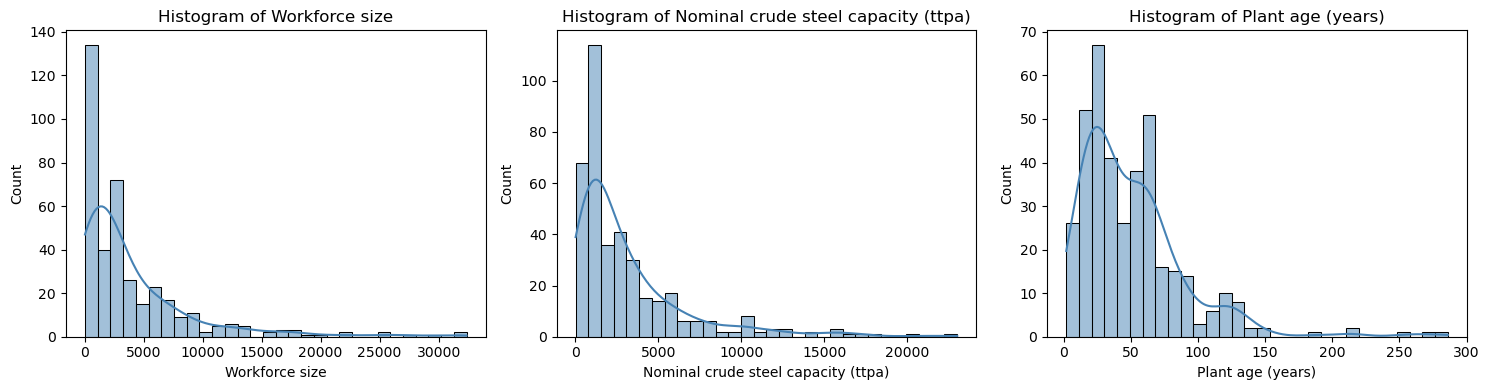

In [22]:
# Columns to plot
columns_to_plot = [
    "Workforce size",
    "Nominal crude steel capacity (ttpa)",
    "Plant age (years)"
]

# Create histograms
plt.figure(figsize=(15, 4))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(1, len(columns_to_plot), i)
    sns.histplot(crude_steel_plants[col], bins=30, kde=True, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    
plt.tight_layout()
plt.show()

Despite the presence of outliers, the data appears consistent and credible. For instance, some factories have exceptionally high production volumes and capacities, which naturally explains the outliers in the number of workers. Similarly, the dataset includes very old facilities (for example, a crude steel factory over 200 years old) which accounts for extreme values in the age variable. Given that these outliers reflect genuine characteristics of the data, treating or removing them would risk distorting the dataset. Therefore, we conclude that no outlier treatment is necessary.



### **Task 1.3 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).  
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.

> *Markdown prompt:*  
Document your new feature(s). What business or operational insight do they represent?

---


In [23]:
# Capacity per Worker
crude_steel_plants['Capacity per Worker (ttpa per worker)'] = (
    crude_steel_plants['Nominal crude steel capacity (ttpa)'] / crude_steel_plants['Workforce size']
)

# Average Annual Growth (%) over 2019–2023
crude_steel_plants['Avg Annual Growth (%)'] = (
    crude_steel_plants[year_cols].pct_change(axis=1).mean(axis=1) * 100
)

New Feature Documentation:
1. Capacity per Worker (ttpa per worker)

    This feature measures labor productivity at each factory, indicating how efficiently the workforce is utilized to produce crude steel. Higher values suggest that a factory achieves greater output per employee, which can reflect operational efficiency, automation, or economies of scale.

2. Average Annual Growth (%) over 2019–2023

    This feature captures the historical growth trend of each factory’s production. It provides a sense of the factory’s performance trajectory, enabling the model to differentiate between consistently expanding facilities and those with stagnant or declining output. This can help identify factors contributing to production growth and improve predictive accuracy for 2023 output.

In [24]:
# Identify categorical columns (object or category type)
categorical_cols = crude_steel_plants.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Identify numeric columns
numeric_cols = crude_steel_plants.select_dtypes(include=['number']).columns.tolist()
print("Numeric columns:", numeric_cols)

Categorical columns: ['Region', 'ISO 14001', 'ISO 50001', 'ResponsibleSteel Certification']
Numeric columns: ['Plant age (years)', 'Workforce size', 'Nominal crude steel capacity (ttpa)', 'production_2019', 'production_2020', 'production_2021', 'production_2022', 'production_2023', 'Capacity per Worker (ttpa per worker)', 'Avg Annual Growth (%)']


In our modeling process, it is necessary to transform categorical variables into numerical representations. To achieve this, we will use two encoding techniques: one-hot encoding and label encoding. We chose one-hot encoding for the 'Region' column, as it contains multiple categories without an inherent order. For the columns related to certifications, we applied label encoding, since these variables were deliberately treated as binary. This approach ensures that the numerical representation accurately reflects the nature of the categorical data, while preserving meaningful relationships for the model.

In [25]:
# One-hot encode categorical variables
encoded_df = pd.get_dummies(crude_steel_plants['Region'], drop_first=True)

# Drop original categorical columns and append encoded ones
crude_steel_plants = pd.concat(
    [crude_steel_plants.drop(columns='Region'), encoded_df],
    axis=1
)

# Create a label encoder instance
le = LabelEncoder()

# Apply label encoding directly to the specified columns
for col in ['ISO 14001', 'ISO 50001', 'ResponsibleSteel Certification']:
    if col in crude_steel_plants.columns:
        # Store original column for reference
        original_values = crude_steel_plants[col].copy()
        
        # Apply label encoding directly to the original column
        crude_steel_plants[col] = le.fit_transform(crude_steel_plants[col].astype(str))

print(f"Shape after encoding: {crude_steel_plants.shape}")
crude_steel_plants.head()

Shape after encoding: (383, 19)


,Plant age (years),Workforce size,ISO 14001,ISO 50001,ResponsibleSteel Certification,Nominal crude steel capacity (ttpa),production_2019,production_2020,production_2021,production_2022,production_2023,Capacity per Worker (ttpa per worker),Avg Annual Growth (%),Asia Pacific,Central & South America,Eurasia,Europe,Middle East,North America
2,79.00,1624.0,1,0,0,2000.0,1100.0,800.0,1252.0,1174.0,1100.00,1.231527,4.173501,False,True,False,False,False,False
3,8.00,787.0,1,0,0,650.0,167.0,182.0,219.0,372.0,356.00,0.825921,23.718411,False,True,False,False,False,False
4,65.13,2993.0,1,1,0,1720.0,878.0,694.0,873.0,922.0,910.00,0.574674,2.286775,False,True,False,False,False,False
5,65.00,3274.0,1,1,0,3501.0,2162.0,1708.0,2148.0,2270.0,2226.00,1.069334,2.125856,False,True,False,False,False,False
6,97.00,3000.0,0,0,1,3200.0,3013.0,3210.0,3257.0,3219.0,3174.75,1.066667,1.365285,True,False,False,False,False,False


Next, we will standardize the numerical data to improve model performance. To achieve this, we will apply a Min-Max scaling transformation, which rescales the values to a consistent range, typically between 0 and 1. This ensures that all features contribute proportionally to the model, prevents variables with larger scales from dominating, and facilitates faster and more stable convergence during training.

In [26]:
scaler = StandardScaler()

# Standardize all numeric columns
crude_steel_plants[numeric_cols] = scaler.fit_transform(crude_steel_plants[numeric_cols])

# Check result
crude_steel_plants[numeric_cols].head()

,Plant age (years),Workforce size,Nominal crude steel capacity (ttpa),production_2019,production_2020,production_2021,production_2022,production_2023,Capacity per Worker (ttpa per worker),Avg Annual Growth (%)
2,0.711428,-0.462953,-0.323678,-0.348353,-0.389496,-0.330083,-0.336311,-0.349320,-0.147797,0.006995
3,-1.076019,-0.626523,-0.711027,-0.501831,-0.489668,-0.500216,-0.469716,-0.471739,-0.253456,1.044798
4,0.362246,-0.195418,-0.404017,-0.384872,-0.406678,-0.392504,-0.378229,-0.380583,-0.318906,-0.093187
5,0.358974,-0.140504,0.106996,-0.173655,-0.242318,-0.182515,-0.154003,-0.164046,-0.190048,-0.101732
6,1.164584,-0.194050,0.020632,-0.033666,0.001142,0.000135,0.003854,-0.007937,-0.190743,-0.142117


In [27]:
# Save the cleaned dataset
crude_steel_plants.to_csv("crude_steel_plants_dataset.csv", index=False)


## 1.4 Feature Relationships and Correlations
*Estimated time: 20–25 min*

### Objective  
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.4.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.  
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.

> *Markdown prompt:*  
Which variables show the strongest correlation with production?  
Do any features appear redundant or highly correlated with each other?

---


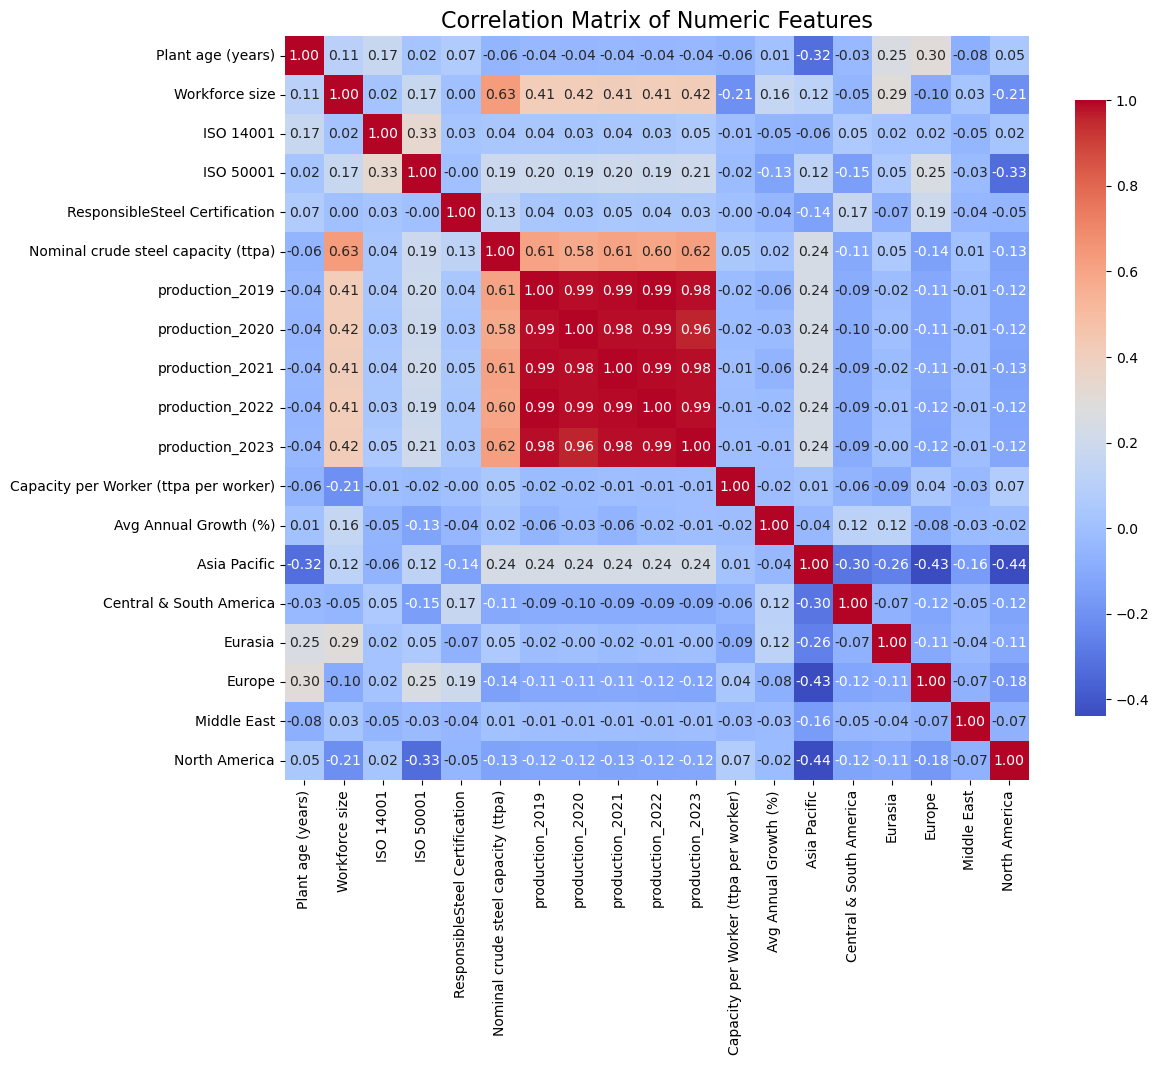

In [28]:
# Select numeric columns
numeric_cols = crude_steel_plants.columns.tolist()

# Compute Pearson correlation
corr_matrix = crude_steel_plants.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation coefficients
    fmt=".2f",         # 2 decimals
    cmap="coolwarm",   # blue-red color map
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

## 2. Building Baseline & Linear Models
*Estimated time: 25–30 min*

### Objective  
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (e.g., mean or median production).  
- Measure RMSE or MAE compared to actual values.

> *Markdown prompt:*  
Why is it useful to have a baseline model before trying more complex ones?

---


In [29]:
# Target year
target_year = "production_2023"
past_years = ["production_2019", "production_2020", "production_2021",
    "production_2022"]

# Baseline: mean of previous years for each plant
baseline_value = crude_steel_plants[past_years].mean(axis=1)

# Predicted values
predicted = baseline_value.values

# Actual values
actual = crude_steel_plants[target_year].values

# Compute RMSE and MAE
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print(f"{target_year} - Baseline prediction (mean of previous years)")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")

production_2023 - Baseline prediction (mean of previous years)
RMSE: 0.19, MAE: 0.04


In machine learning, establishing a baseline model is a critical first step before developing more complex models. A baseline serves as a reference point, providing a minimum standard of performance against which more sophisticated models can be compared. For instance, in a regression problem, predicting the mean of the target variable can serve as a simple baseline. Having a baseline is useful for several reasons. First, it helps gauge the effectiveness of advanced models: if a complex model fails to outperform the baseline, it signals potential issues in feature engineering, model design, or data quality. Second, it prevents unnecessary complexity, ensuring that model development focuses on meaningful improvements rather than over-engineering. Third, a baseline facilitates debugging by revealing errors in data preprocessing, feature handling, or evaluation metrics. Finally, it sets realistic expectations for stakeholders and guides iterative model improvement by quantifying incremental gains.


### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.  
- Display coefficients and interpret their meaning.  
- Evaluate the model on training and test data.

> *Markdown prompt:*  
Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?

---


In [30]:
# Target variable (e.g., 2023 production)
y = crude_steel_plants['production_2023']

# Predictor variables (numeric + engineered features)
feature_cols = [
    'Plant age (years)',
    'Workforce size',
    'Nominal crude steel capacity (ttpa)',
    'Capacity per Worker (ttpa per worker)',
    'Avg Annual Growth (%)',
    'ISO 14001',
    'ISO 50001',
    'ResponsibleSteel Certification',
    'Europe',
    'Eurasia',
    'Middle East',
    'North America',
    'Asia Pacific',
    'Central & South America',
    'production_2019',
    'production_2020',
    'production_2021',
    'production_2022']

X = crude_steel_plants[feature_cols]

In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [33]:
# Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
})

print("Linear Regression Coefficients:")
display(coef_df)

Linear Regression Coefficients:


,Feature,Coefficient
0,Plant age (years),-0.003878
1,Workforce size,0.008488
2,Nominal crude steel capacity (ttpa),0.007726
3,Capacity per Worker (ttpa per worker),0.006606
4,Avg Annual Growth (%),0.050532
5,ISO 14001,0.047295
6,ISO 50001,0.018151
7,ResponsibleSteel Certification,-0.049478
8,Europe,-0.018235
9,Eurasia,0.023985


From the linear regression model, several features show how they influence plant performance:

- **Nominal crude steel capacity (ttpa):** Positive coefficient (0.0077) indicates that plants with higher nominal capacity tend to produce more. However, the effect is modest, suggesting that size alone is not the main driver of performance.

- **Plant age (years):** Slightly negative coefficient (-0.0039) suggests that older plants perform marginally worse than newer ones. This may reflect that newer plants are more technologically advanced and efficient.

- **Capacity per Worker (ttpa per worker):** Positive coefficient (0.0066) highlights the importance of operational efficiency. Plants producing more per worker tend to have higher overall performance, emphasizing productivity over sheer size.

- **Production in 2020:** Large negative coefficient (-0.7966) indicates that unusually high production in 2020 is associated with lower predicted production later. This likely reflects volatility during that year (e.g., COVID-19 disruptions) and shows that past anomalies can strongly influence future predictions.

In [34]:
# Training error
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test error
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Training RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")

Training RMSE: 0.11, MAE: 0.05
Test RMSE: 0.09, MAE: 0.05


The baseline model, which predicts the mean of previous years’ production, achieved an RMSE of 0.19 and an MAE of 0.04. In comparison, the linear regression model performs significantly better, with a training RMSE of 0.11 and MAE of 0.05, and a test RMSE of 0.09 and MAE of 0.05. This improvement indicates that the linear regression is able to capture important patterns from the input features that the baseline ignores, resulting in lower prediction errors on unseen data. Overall, linear regression clearly outperforms the baseline and demonstrates its effectiveness in modeling production trends.

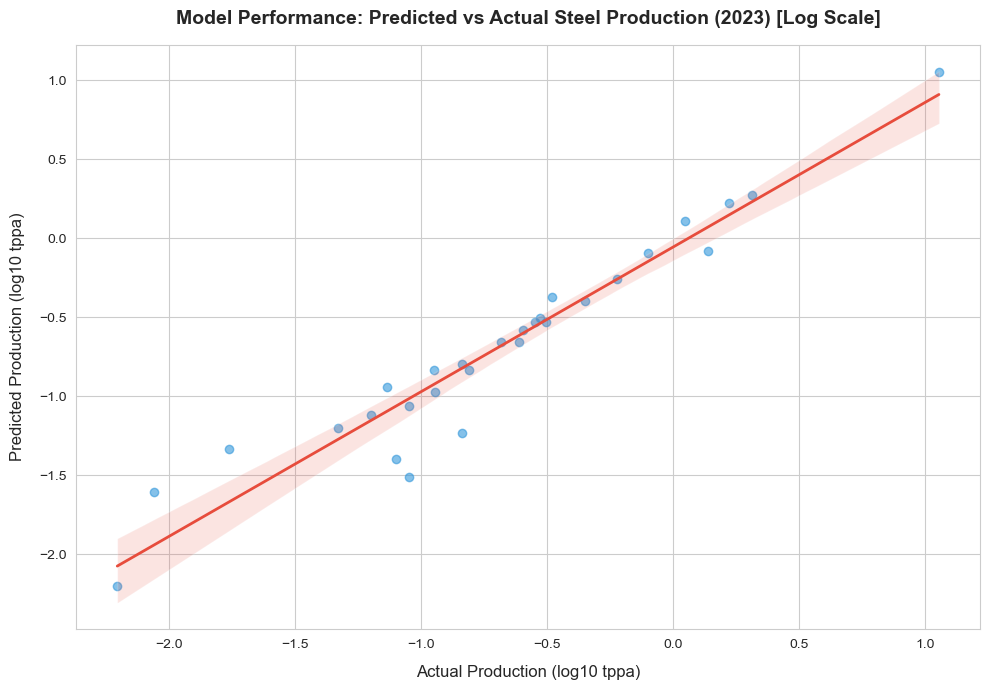

In [35]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))

# Ignore warnings for invalid value in log10
np.seterr(divide='ignore', invalid='ignore')

# Scatter plot with regression line (log scale)
# Avoid log(0) by adding a small constant if needed
epsilon = 1e-1
y_test_log = np.log10(y_test + epsilon)
y_pred_log = np.log10(y_test_pred + epsilon)

scatter = sns.regplot(
    x=y_test_log, 
    y=y_pred_log, 
    scatter_kws={'alpha':0.6, 'color':'#3498db'}, 
    line_kws={'color':'#e74c3c', 'lw':2}
)

# Customize labels and title
plt.xlabel('Actual Production (log10 tppa)', fontsize=12, labelpad=10)
plt.ylabel('Predicted Production (log10 tppa)', fontsize=12, labelpad=10)
plt.title('Model Performance: Predicted vs Actual Steel Production (2023) [Log Scale]', 
          fontsize=14, pad=15, fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()

## 3. Model Evaluation and Selection
*Estimated time: 45–60 min*

### Objective  
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).  
- Record the average RMSE, MAE, and R² across folds.

> *Markdown prompt:*  
Summarize your results. How stable is performance across folds? What might this indicate about model variance?

---


In [36]:
# Features and target
X = crude_steel_plants[feature_cols]  # replace with your numeric/categorical features
y = crude_steel_plants["production_2023"]  # target year

# Initialize model
model = LinearRegression()

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
fold_metrics = []

print("=== 5-Fold Cross-Validation ===\n")
print(f"{'Fold':<6} {'RMSE':<10} {'MAE':<10} {'R²':<10}")
print("-" * 34)

# Cross-validation
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store metrics
    fold_metrics.append({
        'fold': fold,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    })
    
    # Print metrics for current fold
    print(f"{fold:<6} {rmse:<10.2f} {mae:<10.2f} {r2:<10.4f}")

# Calculate and print average metrics
print("-" * 34)
print(f"{'Avg':<6} {np.mean([m['rmse'] for m in fold_metrics]):<10.2f} "
      f"{np.mean([m['mae'] for m in fold_metrics]):<10.2f} "
      f"{np.mean([m['r2'] for m in fold_metrics]):<10.4f}")

# Calculate and print standard deviation
print(f"{'Std':<6} {np.std([m['rmse'] for m in fold_metrics], ddof=1):<10.2f} "
      f"{np.std([m['mae'] for m in fold_metrics], ddof=1):<10.2f} "
      f"{np.std([m['r2'] for m in fold_metrics], ddof=1):<10.4f}")

=== 5-Fold Cross-Validation ===

Fold   RMSE       MAE        R²        
----------------------------------
1      0.09       0.05       0.9956    
2      0.06       0.04       0.9977    
3      0.24       0.06       0.8612    
4      0.12       0.06       0.9709    
5      0.19       0.07       0.9324    
----------------------------------
Avg    0.14       0.06       0.9516    
Std    0.07       0.01       0.0570    


The 5-fold cross-validation results show an average RMSE of 0.14, MAE of 0.06, and R² of 0.9516, with standard deviations of 0.07 (RMSE), 0.01 (MAE), and 0.057 (R²). While most folds exhibit very high performance (R² > 0.93), fold 3 shows noticeably lower performance (R² = 0.8612, RMSE = 0.24).

This variation across folds indicates that the model is not perfectly stable and may be somewhat sensitive to the specific training/validation split. The higher standard deviations, particularly in RMSE and R², suggest the presence of moderate model variance. In practice, this means that while the model generally predicts well, its performance may fluctuate when applied to different subsets of the data, and there could be outlier folds or regions of the feature space where predictions are less accurate.

The model demonstrates strong overall predictive power, but the variability across folds points to moderate variance, signaling that careful evaluation on new or unseen data is important.

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**:
- Linear Regression  
- Ridge Regression (regularized linear)  
- Random Forest Regressor  

Record cross-validation performance for each model.

> *Markdown prompt:*  
Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?

---

In [37]:
# Features and target
X = crude_steel_plants[feature_cols]
y = crude_steel_plants["production_2023"]

# Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=1000, random_state=42)
}

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Custom scorers
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Store cross-validation results
cv_results = []

for name, model in models.items():
    rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring=mae_scorer)
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)
    
    cv_results.append({
        "Model": name,
        "RMSE Mean": rmse_scores.mean(),
        "RMSE Std": rmse_scores.std(),
        "MAE Mean": mae_scores.mean(),
        "MAE Std": mae_scores.std(),
        "R2 Mean": r2_scores.mean(),
        "R2 Std": r2_scores.std()
    })

# Convert to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("=== 5-Fold Cross-Validation Results ===")
display(cv_results_df)

=== 5-Fold Cross-Validation Results ===


,Model,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R2 Mean,R2 Std
0,Linear Regression,0.138765,0.064326,0.057610,0.009043,0.951586,0.050943
1,Ridge Regression,0.144006,0.084212,0.055446,0.008987,0.939719,0.081096
2,Random Forest,0.310659,0.131585,0.066174,0.015701,0.868092,0.105844
3,Gradient Boosting,0.204751,0.123611,0.052554,0.017399,0.873132,0.172541
4,MLP Regressor,0.157774,0.116374,0.064500,0.018046,0.913117,0.134822


Based on the cross-validation results, Linear Regression performs best overall. It achieves the lowest mean RMSE (0.139), competitive MAE (0.058), and the highest R² mean (0.952) among all models. Ridge Regression is close, but its RMSE and R² standard deviations are slightly higher, indicating less stability. Tree-based models like Random Forest and Gradient Boosting have higher RMSEs and more variability across folds, suggesting they are overfitting some subsets of the data. The MLP Regressor is intermediate in performance but also shows high variance across folds.

Why Linear Regression Performs Best:
- **Feature characteristics:** The dataset includes many numeric features and historical production values, which are likely linearly correlated with the target (production_2023). Linear regression naturally captures such linear relationships effectively.

- **Small sample sensitivity:** Tree-based models and neural networks tend to require larger datasets to generalize well. With limited data, they can overfit, producing high variability across folds.

### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).  
- Report the best parameters and corresponding validation score.

> *Markdown prompt:*  
Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?

---


In [38]:
# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 0.9],
    'max_features': ['sqrt', 'log2']
}

# Initialize the base model
gb_model = GradientBoostingRegressor(random_state=42)

# Initialize K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # We'll use negative MSE (higher is better)
    cv=kf,
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Prepare features and target
feature_cols = [col for col in crude_steel_plants.columns if col != 'production_2023']
X = crude_steel_plants[feature_cols]
y = crude_steel_plants['production_2023']

# Fit the grid search model
print("Starting GridSearchCV for Gradient Boosting...")
grid_search.fit(X, y)

# Print the best parameters and corresponding score
print("\n=== Best Parameters ===")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

# Calculate and print the best score (negative MSE, so we convert it to positive RMSE)
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"\nBest RMSE: {best_rmse:.4f}")

Starting GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

=== Best Parameters ===
learning_rate: 0.2
max_depth: 4
max_features: sqrt
min_samples_leaf: 2
min_samples_split: 5
n_estimators: 300
subsample: 0.9

Best RMSE: 0.1979


Hyperparameter tuning is a critical step in optimizing model performance. For Gradient Boosting, tuning allows the model to balance bias and variance by adjusting parameters such as learning rate, tree depth, number of estimators, and subsampling rate. In this case, tuning identified the following optimal parameters: a learning rate of 0.2, maximum tree depth of 4, 300 estimators, subsample of 0.9, and constraints on minimum samples per leaf and split.

Compared to the default settings, tuning slightly improved performance, reducing the RMSE from 0.2048 (default) to 0.1979 (best parameters). This shows that careful selection of hyperparameters can enhance model accuracy and stability, but the improvement is moderate because the dataset has strong linear relationships captured well by simpler models like Linear Regression. Gradient Boosting benefits from tuning, but its complexity makes it more sensitive to dataset size and feature characteristics, which may limit large gains.

Hyperparameter tuning helps optimize complex models, but the magnitude of improvement depends on the dataset. In this case, tuning improved Gradient Boosting slightly, confirming that model selection and hyperparameter optimization must be considered together.

## 4. Model Lifecycle: Tracking, Saving, and Loading
*Estimated time: 30–40 min*

### Objective  
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (plots or model files).  
- Run and record at least two model experiments.

> *Markdown prompt:*  
Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?

---

### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one model (e.g., Ridge or Random Forest).  
- Record the number of trials and best result.

> *Markdown prompt:*  
Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?

---

### **Task 4.3 – Model Storage**
- Save the best performing model to a file (e.g., using joblib or MLflow’s model registry).  
- Demonstrate loading the saved model and re-evaluating it on the test set.

> *Markdown prompt:*  
Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?

---


## 5. Deployment & Monitoring (Conceptual)
*Estimated time: 15–20 min*

### Objective  
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**
> *Markdown prompt:*  
Describe how you would deploy your model in a business environment (e.g., via REST API, batch pipeline).  
Which metrics would you monitor in production?

---

### **Task 5.2 – Detecting Model Drift**
> *Markdown prompt:*  
What signs might indicate your model needs retraining?  
Give one example of **data drift** and one of **concept drift** relevant to steel plant production.

---

## 6. Reflection
*Estimated time: 10–15 min*

> *Markdown prompt:*  
1. Which step of the modelling lifecycle did you find most challenging and why?  
2. What would you do differently if you had access to additional plant-level data?  
3. How would you communicate model insights to a business audience?

---

**End of Lab**

Next week: Short quiz on theoretical concepts (distributions, regression, model selection, and experiment tracking).

